# Metodologia de Avaliação e Partição de Dados

Nesta fase do projeto é definida a estratégia de avaliação do modelo preditivo, incluindo a divisão do conjunto de dados em subconjuntos de treino e teste, a prevenção de fugas de informação (*data leakage*) e a definição das métricas de desempenho adequadas ao problema de regressão.

In [1]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Compatibilidade com versões do sklearn
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

## Leitura e Preparação Inicial dos Dados

Nesta etapa, o dataset é carregado a partir do ficheiro original, sendo aplicadas apenas as operações de limpeza estrutural necessárias para preparar a fase de modelação.

In [2]:
CSV_PATH = "/kaggle/input/datasets/jhonan/airqualityuci/AirQualityUCI.csv"

df = pd.read_csv(CSV_PATH, sep=";", decimal=",")
df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")

print("Dimensão inicial:", df.shape)
display(df.head())

Dimensão inicial: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [3]:
# Substituir -200 por NaN
numeric_cols = [c for c in df.columns if c not in ["Date", "Time"]]
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)

# Criar timestamp
df["timestamp"] = pd.to_datetime(
    df["Date"].astype(str).str.strip() + " " + df["Time"].astype(str).str.strip(),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Limpezas essenciais
df = df.dropna(subset=["timestamp"])
df = df.drop(columns=["NMHC(GT)"], errors="ignore")
df = df.dropna(subset=["CO(GT)"])

# Ordenar temporalmente
df = df.sort_values("timestamp").reset_index(drop=True)

print("Dimensão após limpeza:", df.shape)

Dimensão após limpeza: (7674, 15)


## Criação de Atributos Derivados

Foram criados novos atributos com base na informação temporal e nas leituras dos sensores, permitindo enriquecer o conjunto de dados e melhorar a capacidade explicativa dos modelos.

Estas transformações são determinísticas, não introduzindo risco de fuga de informação.

In [4]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()
df["month"] = df["timestamp"].dt.month.astype(str)

df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
df["is_warm_season"] = df["month"].isin(["6", "7", "8", "9"]).astype(int)

sensor_cols = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]
sensor_cols = [c for c in sensor_cols if c in df.columns]

df["sensor_mean"] = df[sensor_cols].mean(axis=1)

## Definição da Variável-Alvo e Variáveis Preditivas

A variável-alvo do projeto é `CO(GT)`.

As colunas auxiliares (`Date`, `Time` e `timestamp`) não são utilizadas diretamente na modelação.

In [5]:
X = df.drop(columns=["CO(GT)", "Date", "Time", "timestamp"], errors="ignore")
y = df["CO(GT)"]

print("Observações:", len(df))
print("Features:", X.shape[1])

Observações: 7674
Features: 17


## Estratégia de Partição dos Dados

O dataset foi dividido em:

- 80% para treino  
- 20% para teste  

A divisão foi realizada de forma cronológica, garantindo que o modelo é treinado com dados passados e avaliado em dados futuros.

In [6]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (6139, 17)
Teste: (1535, 17)


## Pré-processamento e Prevenção de Data Leakage

As transformações serão ajustadas apenas no conjunto de treino e posteriormente aplicadas ao conjunto de teste, garantindo o isolamento dos dados de avaliação.

In [7]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = X.columns
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - 1.5 * iqr
        self.upper_ = q3 + 1.5 * iqr
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        return X.clip(self.lower_, self.upper_, axis=1).values

In [8]:
categorical = ["day_of_week", "month"]
categorical = [c for c in categorical if c in X.columns]

numerical = [c for c in X.columns if c not in categorical]

In [9]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", IQRClipper()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical),
    ("cat", cat_pipeline, categorical)
])

In [10]:
# Aplicar o pré-processamento (sem data leakage)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Treino transformado:", X_train_processed.shape)
print("Teste transformado:", X_test_processed.shape)

Treino transformado: (6139, 33)
Teste transformado: (1535, 33)


## Estratégia de Validação

Será utilizada validação cruzada com `TimeSeriesSplit`, respeitando a ordem temporal dos dados.

In [11]:
tscv = TimeSeriesSplit(n_splits=5)

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    print(f"Fold {i+1}: treino={len(train_idx)}, validação={len(val_idx)}")

Fold 1: treino=1024, validação=1023
Fold 2: treino=2047, validação=1023
Fold 3: treino=3070, validação=1023
Fold 4: treino=4093, validação=1023
Fold 5: treino=5116, validação=1023


## Métricas de Desempenho

Foram selecionadas métricas de regressão:

- RMSE  
- MAE  
- R²  

Estas permitem avaliar o desempenho dos modelos de forma complementar.

In [12]:
def avaliar(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

## Síntese da Preparação para Modelação

Nesta fase foram definidas as bases metodológicas para a modelação, incluindo a partição dos dados, a estratégia de validação e as métricas de avaliação.

O conjunto de dados encontra-se preparado para a implementação dos primeiros modelos preditivos, que serão desenvolvidos nas etapas seguintes.

## Modelo Baseline

Como ponto de partida, foi utilizado um modelo simples de referência, com o objetivo de estabelecer um patamar mínimo de desempenho.

Este modelo não utiliza as variáveis preditoras, limitando-se a prever sempre o valor médio da variável-alvo.

As métricas obtidas por este modelo serão utilizadas como base comparativa para os modelos mais avançados a implementar nas etapas seguintes.

In [13]:
from sklearn.dummy import DummyRegressor

# Criar modelo baseline
baseline_model = DummyRegressor(strategy="mean")

# Treinar modelo
baseline_model.fit(X_train, y_train)

# Fazer previsões
y_pred_baseline = baseline_model.predict(X_test)

print("Previsões baseline (primeiros valores):")
print(y_pred_baseline[:5])

Previsões baseline (primeiros valores):
[2.1904056 2.1904056 2.1904056 2.1904056 2.1904056]


In [14]:
baseline_results = avaliar(y_test, y_pred_baseline)

print("Resultados do modelo baseline:")
for k, v in baseline_results.items():
    print(f"{k}: {v:.4f}")

Resultados do modelo baseline:
RMSE: 1.3576
MAE: 1.0831
R2: -0.0196


## Modelos Candidatos

Foram testados diferentes algoritmos de regressão com o objetivo de superar o desempenho do modelo baseline.

Os modelos selecionados incluem abordagens lineares e baseadas em ensemble, permitindo comparar diferentes níveis de complexidade e capacidade de generalização.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [17]:
results = []

for name, model in models.items():
    
    # Treinar modelo
    model.fit(X_train_processed, y_train)
    
    # Previsões
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)
    
    # Avaliação
    train_metrics = avaliar(y_train, y_train_pred)
    test_metrics = avaliar(y_test, y_test_pred)
    
    results.append({
        "Modelo": name,
        "RMSE Treino": train_metrics["RMSE"],
        "RMSE Teste": test_metrics["RMSE"],
        "MAE Teste": test_metrics["MAE"],
        "R2 Teste": test_metrics["R2"]
    })

results_df = pd.DataFrame(results)
results_df

,Modelo,RMSE Treino,RMSE Teste,MAE Teste,R2 Teste
0,Linear Regression,0.496785,0.764871,0.617367,0.676374
1,Random Forest,0.134541,0.538657,0.357059,0.839494
2,Gradient Boosting,0.336649,0.507099,0.343789,0.857750


In [18]:
# Recriar tabela SEM baseline primeiro
results_df = pd.DataFrame(results)

# Criar linha do baseline
baseline_row = {
    "Modelo": "Baseline",
    "RMSE Treino": np.nan,
    "RMSE Teste": baseline_results["RMSE"],
    "MAE Teste": baseline_results["MAE"],
    "R2 Teste": baseline_results["R2"]
}

# Adicionar baseline no topo
results_df = pd.concat(
    [pd.DataFrame([baseline_row]), results_df],
    ignore_index=True
)

results_df

,Modelo,RMSE Treino,RMSE Teste,MAE Teste,R2 Teste
0,Baseline,NaN,1.357633,1.083067,-0.019605
1,Linear Regression,0.496785,0.764871,0.617367,0.676374
2,Random Forest,0.134541,0.538657,0.357059,0.839494
3,Gradient Boosting,0.336649,0.507099,0.343789,0.857750


## Síntese da Avaliação dos Modelos

Nesta fase foram testados diferentes algoritmos de regressão com o objetivo de superar o desempenho do modelo baseline.

Os resultados obtidos demonstram que todos os modelos candidatos apresentam melhorias significativas face ao baseline, evidenciando a capacidade dos algoritmos de machine learning em capturar padrões relevantes nos dados.

Os modelos baseados em ensemble, nomeadamente o **Random Forest** e o **Gradient Boosting**, destacaram-se pelo seu desempenho superior, apresentando menores valores de erro (RMSE e MAE) e maior capacidade explicativa (R²).

Em particular, o modelo **Gradient Boosting** revelou-se o mais eficaz, indicando uma melhor capacidade de generalização e adaptação à complexidade dos dados.

Por outro lado, o modelo de **Regressão Linear** apresentou um desempenho inferior, sugerindo que as relações entre as variáveis não são exclusivamente lineares.

De forma geral, conclui-se que modelos mais complexos são mais adequados para este problema, ficando o sistema preparado para a fase seguinte de otimização e ajuste de hiperparâmetros.

## Diagnóstico de Desempenho e Generalização

Nesta fase é analisada a diferença de desempenho entre os conjuntos de treino e teste, com o objetivo de avaliar a capacidade de generalização dos modelos testados.

A comparação entre estas métricas permite identificar possíveis sinais de **overfitting**, quando o modelo apresenta desempenho muito elevado no treino mas degradação no teste, e de **underfitting**, quando o desempenho é fraco em ambos os conjuntos.

In [19]:
diagnostico = []

for _, row in results_df.iterrows():
    modelo = row["Modelo"]

    if modelo == "Baseline":
        continue

    rmse_train = row["RMSE Treino"]
    rmse_test = row["RMSE Teste"]
    diff = rmse_test - rmse_train

    if modelo == "Linear Regression":
        status = "Indícios de underfitting"
    elif diff > 0.30:
        status = "Evidência de overfitting"
    else:
        status = "Melhor capacidade de generalização"

    diagnostico.append({
        "Modelo": modelo,
        "RMSE Treino": rmse_train,
        "RMSE Teste": rmse_test,
        "Diferença RMSE": round(diff, 4),
        "Diagnóstico": status
    })

diagnostico_df = pd.DataFrame(diagnostico)
diagnostico_df

,Modelo,RMSE Treino,RMSE Teste,Diferença RMSE,Diagnóstico
0,Linear Regression,0.496785,0.764871,0.2681,Indícios de underfitting
1,Random Forest,0.134541,0.538657,0.4041,Evidência de overfitting
2,Gradient Boosting,0.336649,0.507099,0.1704,Melhor capacidade de generalização


### Interpretação do Diagnóstico

A análise da discrepância entre treino e teste permite retirar as seguintes conclusões:

- **Regressão Linear:** apresenta erro relativamente elevado nos dois conjuntos, sugerindo capacidade limitada para modelar a complexidade do problema;
- **Random Forest:** apresenta erro muito reduzido no treino e superior no teste, evidenciando sinais de sobreajuste;
- **Gradient Boosting:** apresenta o melhor equilíbrio entre treino e teste, revelando melhor capacidade de generalização.

## Curvas de Aprendizagem

As curvas de aprendizagem permitem analisar como o desempenho do modelo evolui à medida que o número de observações de treino aumenta.

Neste caso, será analisado o modelo **Gradient Boosting**, por ter apresentado o melhor desempenho na etapa anterior.

In [20]:
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt

In [21]:
gb_learning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

tscv_learning = TimeSeriesSplit(n_splits=5)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=gb_learning_pipeline,
    X=X_train,
    y=y_train,
    cv=tscv_learning,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

train_rmse_std = train_scores.std(axis=1)
val_rmse_std = val_scores.std(axis=1)

print("Tamanhos de treino:", train_sizes)
print("RMSE médio treino:", train_rmse)
print("RMSE médio validação:", val_rmse)

Tamanhos de treino: [ 204  409  614  819 1024]
RMSE médio treino: [0.05655516 0.0847795  0.10176643 0.12690415 0.13640081]
RMSE médio validação: [0.57832237 0.63160935 0.6669323  0.86141104 0.79810822]


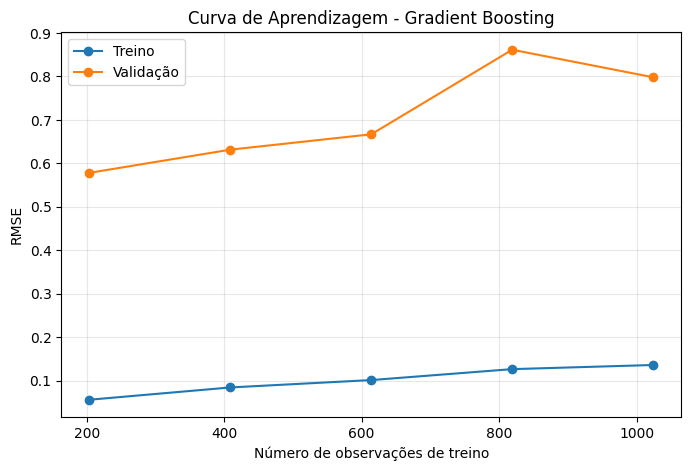

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker="o", label="Treino")
plt.plot(train_sizes, val_rmse, marker="o", label="Validação")

plt.xlabel("Número de observações de treino")
plt.ylabel("RMSE")
plt.title("Curva de Aprendizagem - Gradient Boosting")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

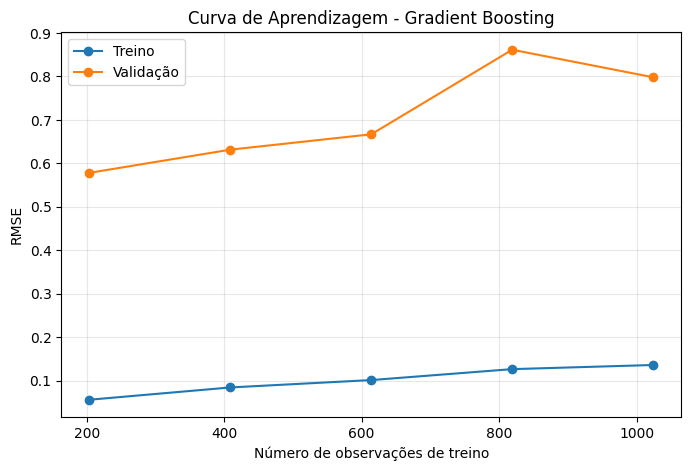

Figura guardada em: /kaggle/working/learning_curve_gradient_boosting.png


In [23]:
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker="o", label="Treino")
plt.plot(train_sizes, val_rmse, marker="o", label="Validação")

plt.xlabel("Número de observações de treino")
plt.ylabel("RMSE")
plt.title("Curva de Aprendizagem - Gradient Boosting")
plt.legend()
plt.grid(True, alpha=0.3)

output_path = "/kaggle/working/learning_curve_gradient_boosting.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada em:", output_path)

## Síntese do Diagnóstico

A análise comparativa entre treino e teste revelou comportamentos distintos entre os modelos testados.

O modelo **Random Forest** apresenta sinais de **overfitting**, uma vez que atinge desempenho muito elevado no treino mas degrada no teste.

O modelo **Regressão Linear** evidencia **underfitting parcial**, mostrando dificuldade em captar a complexidade das relações existentes nos dados.

O modelo **Gradient Boosting** destaca-se por apresentar o melhor equilíbrio entre erro de treino e erro de teste, revelando maior capacidade de generalização.

A curva de aprendizagem do Gradient Boosting indica um comportamento estável, sugerindo que o modelo é robusto, embora ainda possa beneficiar de mais dados ou de otimização adicional de hiperparâmetros.

## Otimização de Hiperparâmetros

Após a comparação inicial entre os modelos candidatos, foi selecionado o **Gradient Boosting** para a fase de otimização, por ter apresentado o melhor desempenho no conjunto de teste e a melhor capacidade de generalização.

Nesta etapa pretende-se identificar uma configuração mais adequada de hiperparâmetros, de forma a melhorar o desempenho do modelo sem comprometer a sua robustez.

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Função de avaliação (fica garantido que existe nesta aula)
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

def avaliar(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

## Estratégia de Validação Cruzada

Para garantir coerência com a natureza temporal do problema, foi utilizada validação cruzada com `TimeSeriesSplit`, em vez de uma divisão aleatória.

Esta abordagem permite avaliar o modelo em múltiplas divisões sequenciais do conjunto de treino, reduzindo a variabilidade dos resultados e aumentando a confiança na estabilidade das métricas obtidas.

In [25]:
tscv_tuning = TimeSeriesSplit(n_splits=5)

for i, (train_idx, val_idx) in enumerate(tscv_tuning.split(X_train), start=1):
    print(f"Fold {i}: treino={len(train_idx)} | validação={len(val_idx)}")

Fold 1: treino=1024 | validação=1023
Fold 2: treino=2047 | validação=1023
Fold 3: treino=3070 | validação=1023
Fold 4: treino=4093 | validação=1023
Fold 5: treino=5116 | validação=1023


## Modelo Base a Comparar

Antes da otimização, será novamente avaliado o modelo **Gradient Boosting com parâmetros por omissão**, de forma a servir como referência direta para comparação com a versão otimizada.

In [26]:
gb_base_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_base_pipeline.fit(X_train, y_train)

y_train_pred_base = gb_base_pipeline.predict(X_train)
y_test_pred_base = gb_base_pipeline.predict(X_test)

base_train_metrics = avaliar(y_train, y_train_pred_base)
base_test_metrics = avaliar(y_test, y_test_pred_base)

print("Desempenho do modelo base - Treino")
for k, v in base_train_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nDesempenho do modelo base - Teste")
for k, v in base_test_metrics.items():
    print(f"{k}: {v:.4f}")

Desempenho do modelo base - Treino
RMSE: 0.3366
MAE: 0.2225
R2: 0.9480

Desempenho do modelo base - Teste
RMSE: 0.5071
MAE: 0.3438
R2: 0.8577


## Definição do Espaço de Pesquisa

Foram selecionados alguns dos hiperparâmetros mais influentes do modelo Gradient Boosting:

- `n_estimators`: número de árvores do ensemble  
- `learning_rate`: taxa de aprendizagem  
- `max_depth`: profundidade máxima das árvores base  

A escolha destes parâmetros justifica-se pelo seu impacto direto na complexidade, capacidade de generalização e estabilidade do modelo.

In [27]:
gb_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

print("Número total de combinações:", 
      len(param_grid["model__n_estimators"]) *
      len(param_grid["model__learning_rate"]) *
      len(param_grid["model__max_depth"]))

Número total de combinações: 27


## Pesquisa de Hiperparâmetros

A otimização foi realizada com `GridSearchCV`, utilizando como métrica principal o **RMSE**. Como o `GridSearchCV` maximiza a pontuação, foi utilizada a versão negativa do RMSE (`neg_root_mean_squared_error`).

In [28]:
grid_search = GridSearchCV(
    estimator=gb_tuning_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv_tuning,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('clipper',
                                                                                          IQRClipper()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['PT08.S1(CO)',
                                                                          'C6H6(GT)',
                                                                          'PT08.S2(NMHC)',
                                                                          'NOx(GT)',
                                                                          'PT08.S3(NOx)',
                                                                          '...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['day_of_week',
                                                                          'month'])])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [2, 3, 4],
                         'model__n_estimators': [50, 100, 150]},
             return_train_score=True, scoring='neg_root_mean_squared_error',
             verbose=1)

In [29]:
best_gb_model = grid_search.best_estimator_
best_params = grid_search.best_params_

cv_results = pd.DataFrame(grid_search.cv_results_)
best_index = grid_search.best_index_

mean_cv_rmse = -cv_results.loc[best_index, "mean_test_score"]
std_cv_rmse = cv_results.loc[best_index, "std_test_score"]

print("Melhores parâmetros finais:")
print(best_params)

print("\nRMSE médio na validação cruzada:")
print(round(mean_cv_rmse, 4))

print("\nDesvio padrão do RMSE:")
print(round(std_cv_rmse, 4))

Melhores parâmetros finais:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}

RMSE médio na validação cruzada:
0.5445

Desvio padrão do RMSE:
0.2467


## Avaliação do Modelo Otimizado

Após a pesquisa, o melhor modelo encontrado foi novamente avaliado no conjunto de treino e no conjunto de teste, permitindo comparar o seu desempenho com o modelo base anteriormente utilizado.

In [30]:
y_train_pred_opt = best_gb_model.predict(X_train)
y_test_pred_opt = best_gb_model.predict(X_test)

opt_train_metrics = avaliar(y_train, y_train_pred_opt)
opt_test_metrics = avaliar(y_test, y_test_pred_opt)

print("Desempenho do modelo otimizado - Treino")
for k, v in opt_train_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nDesempenho do modelo otimizado - Teste")
for k, v in opt_test_metrics.items():
    print(f"{k}: {v:.4f}")

Desempenho do modelo otimizado - Treino
RMSE: 0.3759
MAE: 0.2447
R2: 0.9352

Desempenho do modelo otimizado - Teste
RMSE: 0.4806
MAE: 0.3210
R2: 0.8722


## Comparação entre Modelo Base e Modelo Otimizado

A comparação entre o modelo Gradient Boosting com parâmetros por omissão e a versão otimizada permite verificar se a sintonização dos hiperparâmetros trouxe benefícios reais.

In [31]:
comparacao_tuning = pd.DataFrame([
    {
        "Modelo": "Gradient Boosting (Base)",
        "RMSE Treino": round(base_train_metrics["RMSE"], 4),
        "RMSE Teste": round(base_test_metrics["RMSE"], 4),
        "MAE Teste": round(base_test_metrics["MAE"], 4),
        "R2 Teste": round(base_test_metrics["R2"], 4)
    },
    {
        "Modelo": "Gradient Boosting (Otimizado)",
        "RMSE Treino": round(opt_train_metrics["RMSE"], 4),
        "RMSE Teste": round(opt_test_metrics["RMSE"], 4),
        "MAE Teste": round(opt_test_metrics["MAE"], 4),
        "R2 Teste": round(opt_test_metrics["R2"], 4)
    }
])

comparacao_tuning

,Modelo,RMSE Treino,RMSE Teste,MAE Teste,R2 Teste
0,Gradient Boosting (Base),0.3366,0.5071,0.3438,0.8577
1,Gradient Boosting (Otimizado),0.3759,0.4806,0.3210,0.8722


## Síntese da Otimização

A otimização de hiperparâmetros permitiu refinar o modelo com melhor desempenho identificado anteriormente.

A comparação entre a versão base e a versão otimizada permite verificar se a melhoria obtida justifica a complexidade adicional do processo de pesquisa.

Os resultados desta etapa servirão de base para a escolha do modelo final do projeto.

In [32]:
melhoria_rmse = base_test_metrics["RMSE"] - opt_test_metrics["RMSE"]
melhoria_mae = base_test_metrics["MAE"] - opt_test_metrics["MAE"]
melhoria_r2 = opt_test_metrics["R2"] - base_test_metrics["R2"]

print("Ganho no RMSE:", round(melhoria_rmse, 4))
print("Ganho no MAE:", round(melhoria_mae, 4))
print("Ganho no R²:", round(melhoria_r2, 4))

Ganho no RMSE: 0.0265
Ganho no MAE: 0.0227
Ganho no R²: 0.0145
